<a href="https://colab.research.google.com/github/vanshika704/celebal/blob/main/week2_vanshika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEAD:
    Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2   

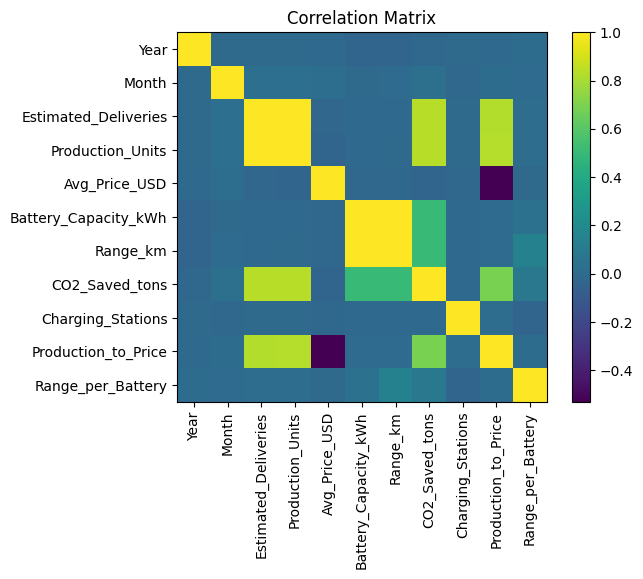

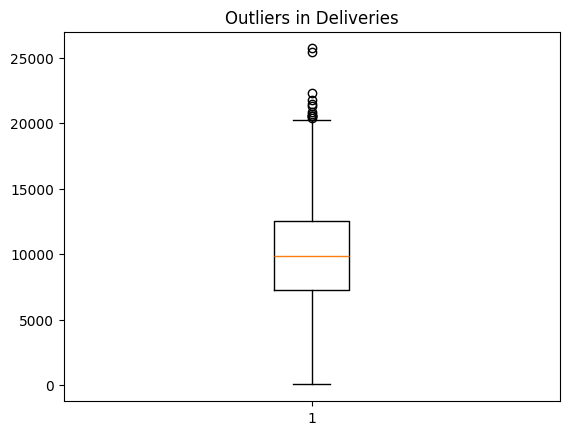


Linear Regression Results:
MSE: 147265.70295780947
R2 Score: 0.9901205651175059

Ridge Regression Results:
Best Alpha: {'alpha': 0.1}
MSE: 147255.25840950702
R2 Score: 0.990121265798199


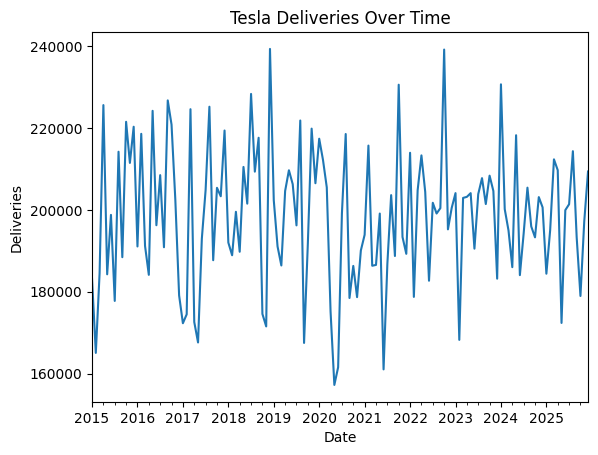


Next 12 Months Forecast:
[198436.5710155  198436.45941537 198436.34781524 198436.2362151
 198436.12461497 198436.01301484 198435.90141471 198435.78981458
 198435.67821445 198435.56661432 198435.45501418 198435.34341405]


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. LOAD DATA
data = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

# 2. BASIC EDA
print("HEAD:\n", data.head(), "\n")
print("TAIL:\n", data.tail(), "\n")
print("COLUMNS:\n", data.columns, "\n")
print("DESCRIBE:\n", data.describe(), "\n")
print("INFO:\n")
data.info()
print("\nSHAPE:", data.shape)

# 3. DATA CLEANING
print("\nMissing Values:\n", data.isnull().sum())
print("Duplicates:", data.duplicated().sum())

data = data.drop_duplicates()


data["Production_to_Price"] = data["Production_Units"] / data["Avg_Price_USD"]
data["Range_per_Battery"] = data["Range_km"] / data["Battery_Capacity_kWh"]

# 4. VISUALIZATION

# Correlation matrix
plt.figure()
corr = data.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

# Outlier detection
plt.figure()
plt.boxplot(data["Estimated_Deliveries"])
plt.title("Outliers in Deliveries")
plt.show()

# 5. ENCODING
data = pd.get_dummies(data, columns=["Region", "Model", "Source_Type"], drop_first=True)

# 6. TRAIN-TEST SPLIT
X = data.drop("Estimated_Deliveries", axis=1)
y = data["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. FEATURE SCALING
scaler = StandardScaler()

num_cols = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Production_to_Price",
    "Range_per_Battery"
]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 8. LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\nLinear Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# 9. RIDGE REGRESSION + TUNING
ridge = Ridge()
params = {"alpha": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(ridge, params, cv=5, scoring="r2")
grid.fit(X_train, y_train)

best_ridge = grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print("\nRidge Regression Results:")
print("Best Alpha:", grid.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

# 10. TIME SERIES FORECASTING

data["Date"] = pd.to_datetime(data[["Year", "Month"]].assign(DAY=1))
ts = data.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure()
ts.plot()
plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.show()

# Proper time index
ts = ts.reset_index()
ts = ts.sort_values("Date")
ts["time_index"] = range(len(ts))

X_ts = ts[["time_index"]]
y_ts = ts["Estimated_Deliveries"]

ts_model = LinearRegression()
ts_model.fit(X_ts, y_ts)

future = pd.DataFrame({
    "time_index": range(len(ts), len(ts) + 12)
})

forecast = ts_model.predict(future)

print("\nNext 12 Months Forecast:")
print(forecast)